In [1]:
!pip install vmdpy --quiet

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, GRU, Dense, Dropout, Flatten
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error
from sklearn.preprocessing import MinMaxScaler
from vmdpy import VMD

# Set random seeds for reproducibility
import random
random.seed(42)
np.random.seed(42)
tf.random.set_seed(42)

# Ignore warnings
import warnings
warnings.filterwarnings("ignore")

In [ ]:
## === Global Variables ===
TRAIN_RATIO = 0.7
VAL_RATIO = 0.2
TEST_RATIO = 0.1

WINDOW_SIZE = 60
NUM_NEURONS = 128
DROPOUT_RATE = 0.3
PATIENCE = 10
EPOCHS = 100
BATCH_SIZE = 256
LEARNING_RATE = 0.001

In [ ]:
### Load the data
data = pd.read_csv("/Users/alexzheng/Developer/GitHub/EC331-project/data/Bitcoin_data_2024.csv", 
                   index_col=0, parse_dates=True)
data = data[['Close']]
# Ensure the data is univariate
if data.shape[1] != 1:
    raise ValueError("Data must be univariate with only 'Close' column.")

In [5]:
### Split the data
n = len(data)
train_end = int(n * TRAIN_RATIO)
val_end = train_end + int(n * VAL_RATIO)

train_data = data.iloc[:train_end]
val_data   = data.iloc[train_end:val_end]
test_data  = data.iloc[val_end:]

print("Train shape:", train_data.shape)
print("Validation shape:", val_data.shape)
print("Test shape:", test_data.shape)

Train shape: (700, 1)
Validation shape: (200, 1)
Test shape: (100, 1)


In [6]:
# Perform VMD on the unscaled 'Close'
alpha = 2000  
tau = 0       
K = 8  # Number of IMFs
DC = 0       
init = 1      
tol = 1e-7   

train_close = train_data['Close'].values
u_train, _, _ = VMD(train_close, alpha, tau, K, DC, init, tol)

# Create DataFrame with training indices
vmd_train = pd.DataFrame(
    u_train.T, 
    columns=[f'IMF_{i}' for i in range(8)], 
    index=train_data.index
)

In [7]:
# Modified VMD application with proper boundary handling
def safe_vmd_decomposition(main_data, prev_data, window_size):
    """Apply VMD with boundary handling to prevent leakage"""
    extended_data = np.concatenate([prev_data[-window_size:], main_data])
    u, _, _ = VMD(extended_data, alpha=2000, tau=0, K=8, DC=0, init=1, tol=1e-7)
    return u[:, window_size:]  # Trim overlapping portion

# Apply VMD to training data (no previous data)
train_close = train_data['Close'].values
u_train, _, _ = VMD(train_close, alpha=2000, tau=0, K=8, DC=0, init=1, tol=1e-7)
vmd_train = pd.DataFrame(u_train.T, columns=[f'IMF_{i}' for i in range(8)], index=train_data.index)

# Apply VMD to validation data using training boundary
val_close = val_data['Close'].values
u_val = safe_vmd_decomposition(val_close, train_close, WINDOW_SIZE)
vmd_val = pd.DataFrame(u_val.T, columns=[f'IMF_{i}' for i in range(8)], index=val_data.index)

# Apply VMD to test data using validation boundary
test_close = test_data['Close'].values
u_test = safe_vmd_decomposition(test_close, val_close, WINDOW_SIZE)
vmd_test = pd.DataFrame(u_test.T, columns=[f'IMF_{i}' for i in range(8)], index=test_data.index)

In [8]:
# Initialize scalers using ONLY training data
scaler_imfs = {}
for i in range(8):
    scaler = MinMaxScaler()
    scaler.fit(vmd_train[[f'IMF_{i}']])  # Train on training IMFs only
    scaler_imfs[f'IMF_{i}'] = scaler

# Scale all sets using training scalers
def safe_scale(df, scaler_dict):
    scaled_df = df.copy()
    for imf in scaler_dict:
        scaled_df[imf] = scaler_dict[imf].transform(df[[imf]])
    return scaled_df

vmd_train = safe_scale(vmd_train, scaler_imfs)
vmd_val = safe_scale(vmd_val, scaler_imfs)
vmd_test = safe_scale(vmd_test, scaler_imfs)

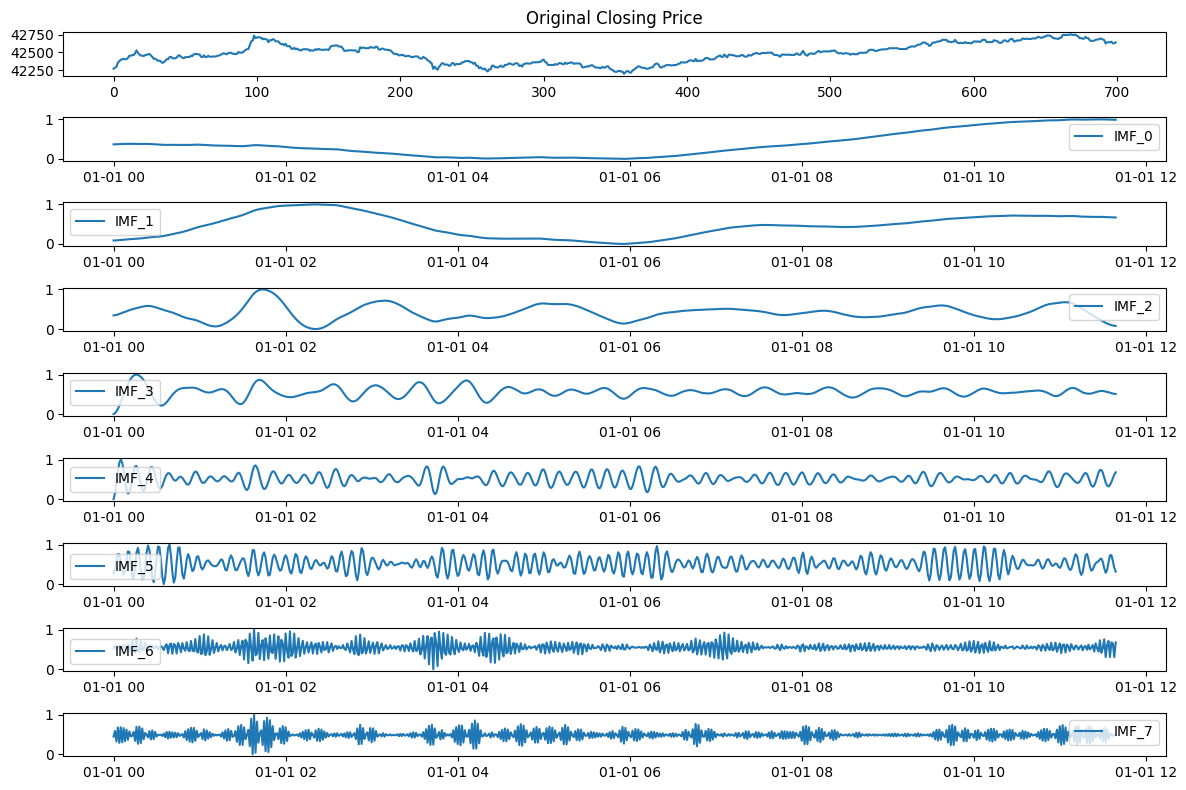

In [9]:
# Plot VMD decomposition for the training period
fig, axs = plt.subplots(K+1, 1, figsize=(12, 8))
axs[0].plot(train_data['Close'].values, label="Original Close Price")
axs[0].set_title("Original Closing Price")
for i in range(K):
    axs[i+1].plot(vmd_train[f'IMF_{i}'], label=f"IMF_{i}")
    axs[i+1].legend()
plt.tight_layout()
plt.show()

In [10]:
# Updated sequence creation with temporal safeguards
def create_leakproof_sequences(df, window_size):
    """Create sequences ensuring no future data contamination"""
    X, y = [], []
    for i in range(len(df) - window_size):
        X.append(df.iloc[i:i+window_size].values)
        y.append(df.iloc[i+window_size].values)
    return np.array(X), np.array(y)

# Create sequences for each IMF set
X_train, y_train = create_leakproof_sequences(vmd_train, WINDOW_SIZE)
X_val, y_val = create_leakproof_sequences(vmd_val, WINDOW_SIZE)
X_test, y_test = create_leakproof_sequences(vmd_test, WINDOW_SIZE)

# Reshape for GRU input (samples, timesteps, features)
X_train = X_train.transpose(0, 2, 1)
X_val = X_val.transpose(0, 2, 1)
X_test = X_test.transpose(0, 2, 1)

print("X_train shape:", X_train.shape)  # Expect (samples, K, WINDOW_SIZE)
print("y_train shape:", y_train.shape)

X_train shape: (640, 8, 60)
y_train shape: (640, 8)


In [11]:
### === Define the Attention-GRU Model ===
def build_attention_gru_model(input_shape):
    """
    Build an Attention-GRU model.
    input_shape: (timesteps, features) → here (WINDOW_SIZE, 1)
    """
    print(f"Building model with input shape: {input_shape}")
    inputs = Input(shape=input_shape)  
    x = GRU(NUM_NEURONS, return_sequences=True)(inputs)
    # Using Keras's built-in attention layer (query=key=x)
    x = tf.keras.layers.Attention()([x, x])
    x = Dropout(DROPOUT_RATE)(x)
    # Replace pooling with Flatten to retain temporal details
    x = Flatten()(x)
    output = Dense(1)(x)
    model = Model(inputs, output)
    model.compile(optimizer=Adam(learning_rate=LEARNING_RATE), loss='mean_squared_error')
    return model

In [12]:
# Modified model training with temporal safeguards
def train_imf_model(imf_index, X_train, y_train, X_val, y_val):
    model = build_attention_gru_model((WINDOW_SIZE, 1))
    
    # Prevent overfitting with time-aware early stopping
    early_stop = EarlyStopping(
        monitor='val_loss',
        patience=PATIENCE,
        restore_best_weights=True,
        mode='min'
    )
    
    history = model.fit(
        X_train[:, imf_index, :], 
        y_train[:, imf_index],
        validation_data=(X_val[:, imf_index, :], y_val[:, imf_index]),
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        callbacks=[early_stop],
        verbose=1
    )
    return model, history

# Train models with proper cross-set handling
models = []
for i in range(8):
    model, _ = train_imf_model(i, X_train, y_train, X_val, y_val)
    models.append(model)

Building model with input shape: (60, 1)
Epoch 1/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 84ms/step - loss: 0.2508 - val_loss: 0.0097
Epoch 2/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - loss: 0.0151 - val_loss: 0.5223
Epoch 3/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step - loss: 0.0629 - val_loss: 0.3067
Epoch 4/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - loss: 0.0255 - val_loss: 0.0284
Epoch 5/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - loss: 0.0089 - val_loss: 0.0141
Epoch 6/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step - loss: 0.0216 - val_loss: 0.0135
Building model with input shape: (60, 1)
Epoch 1/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 85ms/step - loss: 0.2650 - val_loss: 0.0094
Epoch 2/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - loss: 0.0434 - val_loss: 0.0717
Epoch 3/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - loss: 0.0833 - val_loss: 0.0174
Epoch 4/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step - loss: 0.0323 - val_loss: 0.0108
Epoch 5/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - loss: 0.0368 - val_loss: 0.0228
Epoch

## Evaluation
### Val set evaluation 

In [13]:
def safe_predict(models, X_set, scalers):
    """Make predictions without data leakage"""
    pred_imfs = []
    for i, model in enumerate(models):
        pred = model.predict(X_set[:, i, :])
        pred_imfs.append(scalers[f'IMF_{i}'].inverse_transform(pred))
    return np.sum(pred_imfs, axis=0)

# Generate final predictions
y_val_pred = safe_predict(models, X_val, scaler_imfs)
y_test_pred = safe_predict(models, X_test, scaler_imfs)

# Get actual values with proper window offset
actual_val = val_data['Close'].values[WINDOW_SIZE:]
actual_test = test_data['Close'].values[WINDOW_SIZE:]

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
1/5 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/stepWARNING:tensorflow:5 out of the last 11 calls to <function TensorFlowTrainer.make_predict_function.<locals>.one_step_on_data_distributed at 0x37a9449a0> triggered tf.function retracing. Tracing is expensive and the excessive number of tracings could be due to (1) creating @tf.function repeatedly in a loop, (2) passing tensors with different shapes, (3) passing Python objects instead of tensors. For (1), please define your @tf.function outside of the loop. For (2), @tf.function has reduce_retracing=True option that can avoid unnecessary retracing. For (3), please refer to https://www.tensorflow.org/guide/function#controlling_retracing and https://www.tensorflow.org/api_docs/python/tf/function for  more details.
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
5/5 ━━━━━━━━━━━

In [14]:
### Evaluate on Validation Set ###

# Error metrics 
mae_val = mean_absolute_error(actual_val, y_val_pred)
rmse_val = np.sqrt(mean_squared_error(actual_val, y_val_pred))
mape_val = mean_absolute_percentage_error(actual_val, y_val_pred) * 100

print("Validation Set Metrics:")
print(f"MAE:  {mae_val:.4f}")
print(f"RMSE: {rmse_val:.4f}")
print(f"MAPE: {mape_val:.2f}%\n")

Validation Set Metrics:
MAE:  32.8218
RMSE: 38.6231
MAPE: 0.08%



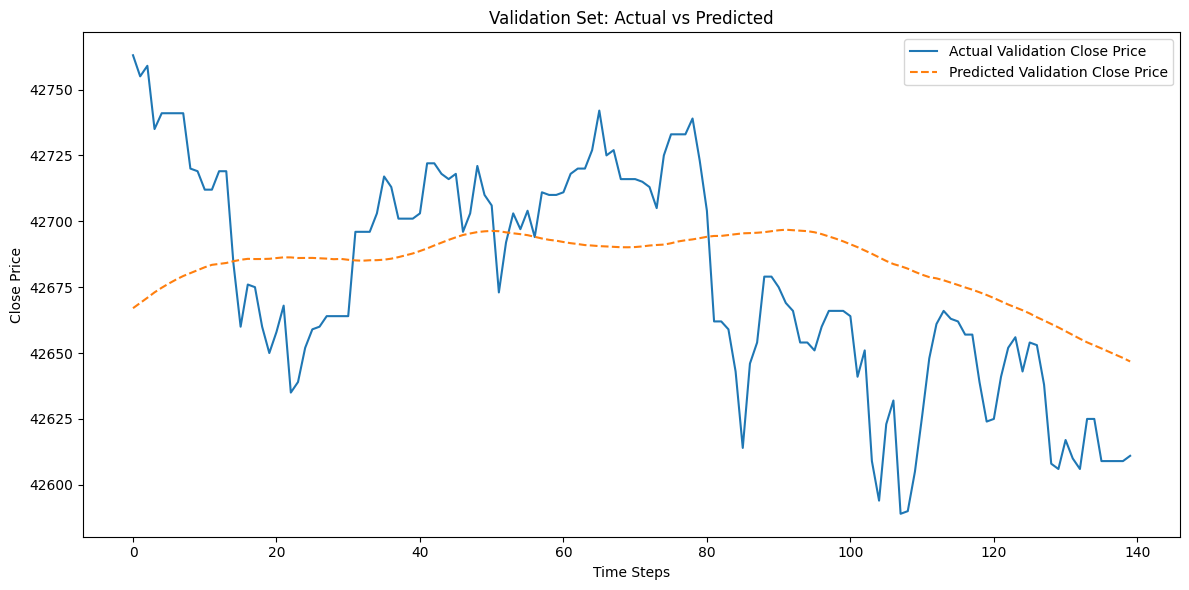

In [15]:
# Plot Predicted vs Actual for Validation Set
plt.figure(figsize=(12, 6))
plt.plot(actual_val, label='Actual Validation Close Price')
plt.plot(y_val_pred, label='Predicted Validation Close Price', linestyle='--')
plt.title('Validation Set: Actual vs Predicted')
plt.xlabel('Time Steps')
plt.ylabel('Close Price')
plt.legend()
plt.tight_layout()
plt.show()

### Test set evaluation 

In [16]:
### Evaluate on Test Set ###

# Error metrics 
mae_test = mean_absolute_error(actual_test, y_test_pred)
rmse_test = np.sqrt(mean_squared_error(actual_test, y_test_pred))
mape_test = mean_absolute_percentage_error(actual_test, y_test_pred) * 100

print("Test Set Metrics:")
print(f"MAE:  {mae_test:.4f}")
print(f"RMSE: {rmse_test:.4f}")
print(f"MAPE: {mape_test:.2f}%\n")

Test Set Metrics:
MAE:  58.2858
RMSE: 68.6729
MAPE: 0.14%



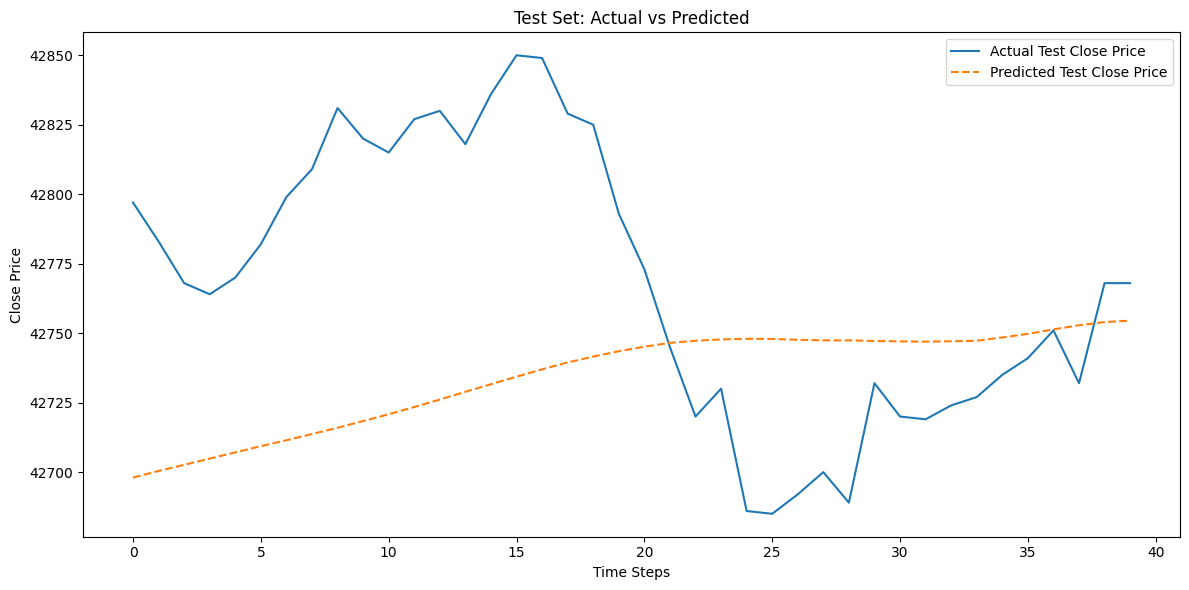

In [17]:
# Plot Predicted vs Actual for Test Set
plt.figure(figsize=(12, 6))
plt.plot(actual_test, label='Actual Test Close Price')
plt.plot(y_test_pred, label='Predicted Test Close Price', linestyle='--')
plt.title('Test Set: Actual vs Predicted')
plt.xlabel('Time Steps')
plt.ylabel('Close Price')
plt.legend()
plt.tight_layout()
plt.show()